# User Location Action Analytics

Read-only notebook for weekly usage, feature/action mix, and retained-user analysis from Supabase `public.user_location_actions`. If `public.app_analytics_events` is available, the notebook also adds event/feature usage plots.

## Setup

Requires the repo dependencies plus local Supabase credentials through `.env`, environment variables, or Secret Manager. The existing `pinit.config.secrets` module looks for `SUPABASE_URL` and `SUPABASE_SERVICE_KEY` / `SUPABASE_SERVICE_ROLE_KEY`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "pinit").exists() and (candidate / "supabase").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pinit.integrations.supabase import get_supabase_service


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

OUTPUT_DIR = PROJECT_ROOT / "output" / "analytics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional date bounds. Leave as None for all available history.
SINCE = None  # Example: "2026-01-01"
UNTIL = None  # Example: "2026-06-30"
PAGE_SIZE = 1000

PROJECT_ROOT, OUTPUT_DIR

Secret 'supabase-service-key' not found in environment or Secret Manager
Secret 'gemini-api-key' not found in environment or Secret Manager


(PosixPath('/Users/sriharshavitta/Projects/pinit-recommendations'),
 PosixPath('/Users/sriharshavitta/Projects/pinit-recommendations/output/analytics'))

## Pull Data From Supabase

In [2]:
db = get_supabase_service()


def fetch_table(
    table_name: str,
    select: str = "*",
    order_col: str | None = None,
    date_col: str | None = None,
    since: str | None = None,
    until: str | None = None,
    page_size: int = PAGE_SIZE,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    start = 0

    while True:
        query = db.client.table(table_name).select(select)
        if date_col and since:
            query = query.gte(date_col, since)
        if date_col and until:
            query = query.lte(date_col, until)
        if order_col:
            query = query.order(order_col)

        response = query.range(start, start + page_size - 1).execute()
        batch = response.data or []
        rows.extend(batch)
        if len(batch) < page_size:
            break
        start += page_size

    return pd.DataFrame(rows)


actions = fetch_table(
    "user_location_actions",
    select="action_id,user_id,location_id,action,created_at,saved_method,preference,acked,source_video_url",
    order_col="created_at",
    date_col="created_at",
    since=SINCE,
    until=UNTIL,
)

users = fetch_table(
    "users",
    select="supabase_id,name,username,email,created_at,wizard_completed,verified",
    order_col="created_at",
)

events = pd.DataFrame()
try:
    events = fetch_table(
        "app_analytics_events",
        select="id,occurred_at,event_name,session_id,user_id,anon_id,feature_name",
        order_col="occurred_at",
        date_col="occurred_at",
        since=SINCE,
        until=UNTIL,
    )
except Exception as exc:
    print(f"Skipping app_analytics_events: {exc}")

print(f"Fetched {len(actions):,} user_location_actions")
print(f"Fetched {len(users):,} users")
print(f"Fetched {len(events):,} app_analytics_events")
actions.head()

Fetched 1,394 user_location_actions
Fetched 241 users
Fetched 3,496 app_analytics_events


,action_id,user_id,location_id,action,created_at,saved_method,preference,acked,source_video_url
0,279,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,1746,dislike,2026-01-12T12:32:14.641107,None,None,True,None
1,280,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,1745,dislike,2026-01-12T12:32:15.333479,None,None,True,None
2,282,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,1743,save,2026-01-12T12:32:16.499536,in-app,None,True,None
3,337,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,1742,dislike,2026-02-17T23:34:54.874244,None,None,True,None
4,391,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,24349,save,2026-04-03T18:53:26.08387,tiktok,None,True,https://vm.tiktok.com/ZNRXFe3nB/


In [3]:
users

,supabase_id,name,username,email,created_at,wizard_completed,verified
0,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,Sri,help,123@gmail.com,2026-01-12T12:31:57.941121,True,False
1,a7e27f73-1bc5-461c-b3cb-fdad3813d139,Kailavya,kailavyakumar9155,kumak113.319@gmail.com,2026-04-15T11:23:39.647279,True,False
2,4b4538bf-b0dd-4533-ae88-0762e28e8281,Shlok,user5257,ishlokshah5@gmail.com,2026-04-15T11:26:31.142463,True,True
3,cb9c8a52-581b-466f-9a76-588532c4b5e9,Sri,sriharshavitta6372,sriharsha.vitta@gmail.com,2026-04-15T11:58:42.927157,True,False
4,d8c37612-57fb-4232-a062-685ffceebeca,Sriharsha Vitta,sriharshavitta6756,sriharsha.vitta@icloud.com,2026-04-15T12:22:05.498436,True,False
...,...,...,...,...,...,...,...
236,9bd8fb65-f7ad-4da2-a2ca-e3852ddf66c5,Hattie,hattiel,hattieleaf66@gmail.com,2026-06-21T21:30:40.798667,True,False
237,aca9c0d4-bd99-47ba-b5af-ff25e3344441,João Cadidé de Souza,joocadiddesouza1301,joaocadide@gmail.com,2026-06-22T15:39:54.827185,True,False
238,82e01c17-bb5f-4b52-a17a-0aa6e1438c84,Stephanie Cunningham-Norton,stephaniecunninghamnorton9997,stephcnorton@gmail.com,2026-06-23T07:26:35.049661,True,False
239,031e1122-da59-4de4-8131-fa500d961f9e,Tessa,tessa9147,tessa.j.4179@gmail.com,2026-06-24T14:53:07.661886,True,False


## Clean And Enrich

In [4]:
if actions.empty:
    raise ValueError("No user_location_actions rows returned. Check credentials, RLS, or date filters.")

actions = actions.copy()
actions["created_at"] = pd.to_datetime(actions["created_at"], errors="coerce")
actions = actions.dropna(subset=["created_at"])
actions["user_id"] = actions["user_id"].astype("string")
actions["action"] = actions["action"].astype("string").fillna("unknown")
actions["week"] = actions["created_at"].dt.to_period("W-MON").dt.start_time
actions["date"] = actions["created_at"].dt.date
actions["has_video_url"] = actions["source_video_url"].notna()

if not events.empty:
    events = events.copy()
    events["occurred_at"] = pd.to_datetime(events["occurred_at"], errors="coerce", utc=True)
    events = events.dropna(subset=["occurred_at"])
    events["event_user_key"] = events["user_id"].fillna(events["anon_id"]).astype("string")
    events["feature_or_event"] = events["feature_name"].fillna(events["event_name"]).astype("string")
    events["week"] = events["occurred_at"].dt.tz_convert(None).dt.to_period("W-MON").dt.start_time

date_min = actions["created_at"].min()
date_max = actions["created_at"].max()
summary = pd.DataFrame(
    {
        "metric": [
            "actions",
            "active_users",
            "touched_locations",
            "first_action_at",
            "last_action_at",
        ],
        "value": [
            f"{len(actions):,}",
            f"{actions['user_id'].nunique():,}",
            f"{actions['location_id'].nunique():,}",
            date_min,
            date_max,
        ],
    }
)
summary

,metric,value
0,actions,"1,394"
1,active_users,87
2,touched_locations,"1,017"
3,first_action_at,2026-01-12 12:32:14.641107
4,last_action_at,2026-06-26 09:11:13.576794


## Weekly Usage Stats

In [5]:
weekly_usage = (
    actions.groupby("week")
    .agg(
        actions=("action_id", "count"),
        active_users=("user_id", "nunique"),
        touched_locations=("location_id", "nunique"),
        video_actions=("has_video_url", "sum"),
    )
    .reset_index()
)

weekly_actions = (
    actions.pivot_table(index="week", columns="action", values="action_id", aggfunc="count", fill_value=0)
    .sort_index()
)

if "users" in globals() and not users.empty and "created_at" in users.columns:
    user_created_at = pd.to_datetime(users["created_at"], errors="coerce")
    weekly_signups = (
        pd.DataFrame({"week": user_created_at.dt.to_period("W-MON").dt.start_time})
        .dropna(subset=["week"])
        .value_counts("week")
        .rename("new_users")
        .reset_index()
    )
else:
    weekly_signups = pd.DataFrame(columns=["week", "new_users"])

growth_weeks = pd.Index(
    sorted(set(weekly_usage["week"].dropna()) | set(weekly_signups["week"].dropna()))
)
weekly_growth = pd.DataFrame({"week": growth_weeks})
weekly_growth = weekly_growth.merge(weekly_usage, on="week", how="left")
weekly_growth = weekly_growth.merge(weekly_signups, on="week", how="left")

growth_base_metrics = ["new_users", "actions", "active_users", "touched_locations", "video_actions"]
weekly_growth[growth_base_metrics] = weekly_growth[growth_base_metrics].fillna(0).astype(int)
weekly_growth["cumulative_users"] = weekly_growth["new_users"].cumsum()

for metric in growth_base_metrics:
    previous = weekly_growth[metric].shift(1)
    weekly_growth[f"{metric}_wow_delta"] = weekly_growth[metric] - previous
    weekly_growth[f"{metric}_wow_pct"] = np.where(
        previous > 0,
        weekly_growth[f"{metric}_wow_delta"] / previous,
        np.nan,
    )

growth_display_columns = [
    "week",
    "new_users",
    "new_users_wow_delta",
    "new_users_wow_pct",
    "cumulative_users",
    "actions",
    "actions_wow_delta",
    "actions_wow_pct",
    "active_users",
    "active_users_wow_delta",
    "active_users_wow_pct",
    "touched_locations",
    "touched_locations_wow_delta",
    "video_actions",
    "video_actions_wow_delta",
]

weekly_usage.to_csv(OUTPUT_DIR / "weekly_usage.csv", index=False)
weekly_actions.to_csv(OUTPUT_DIR / "weekly_actions_by_type.csv")
weekly_growth.to_csv(OUTPUT_DIR / "weekly_growth.csv", index=False)

weekly_growth[growth_display_columns].tail(12)

,week,actions,actions_wow_delta,actions_wow_pct,active_users,active_users_wow_delta,active_users_wow_pct,touched_locations,touched_locations_wow_delta,video_actions,video_actions_wow_delta
3,2026-04-07,49,38.0,3.454545,1,0.0,0.000000,47,36.0,24,13.0
4,2026-04-14,185,136.0,2.775510,15,14.0,14.000000,138,91.0,58,34.0
5,2026-04-21,166,-19.0,-0.102703,17,2.0,0.133333,135,-3.0,100,42.0
6,2026-04-28,189,23.0,0.138554,23,6.0,0.352941,160,25.0,73,-27.0
7,2026-05-05,195,6.0,0.031746,30,7.0,0.304348,181,21.0,92,19.0
8,2026-05-12,115,-80.0,-0.410256,23,-7.0,-0.233333,106,-75.0,59,-33.0
9,2026-05-19,147,32.0,0.278261,29,6.0,0.260870,130,24.0,72,13.0
10,2026-05-26,130,-17.0,-0.115646,21,-8.0,-0.275862,120,-10.0,57,-15.0
11,2026-06-02,76,-54.0,-0.415385,11,-10.0,-0.476190,75,-45.0,56,-1.0
12,2026-06-09,49,-27.0,-0.355263,8,-3.0,-0.272727,46,-29.0,25,-31.0


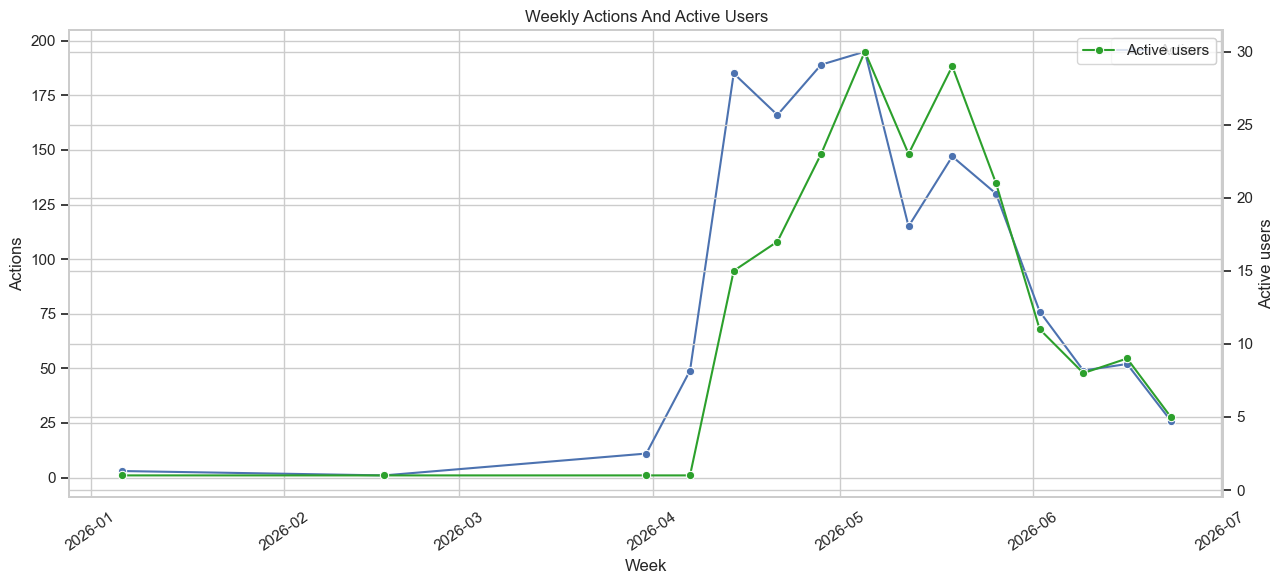

In [6]:
fig, ax1 = plt.subplots(figsize=(13, 6))
sns.lineplot(data=weekly_usage, x="week", y="actions", marker="o", ax=ax1, label="Actions")
ax1.set_xlabel("Week")
ax1.set_ylabel("Actions")

ax2 = ax1.twinx()
sns.lineplot(
    data=weekly_usage,
    x="week",
    y="active_users",
    marker="o",
    ax=ax2,
    color="tab:green",
    label="Active users",
)
ax2.set_ylabel("Active users")
ax1.set_title("Weekly Actions And Active Users")
ax1.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

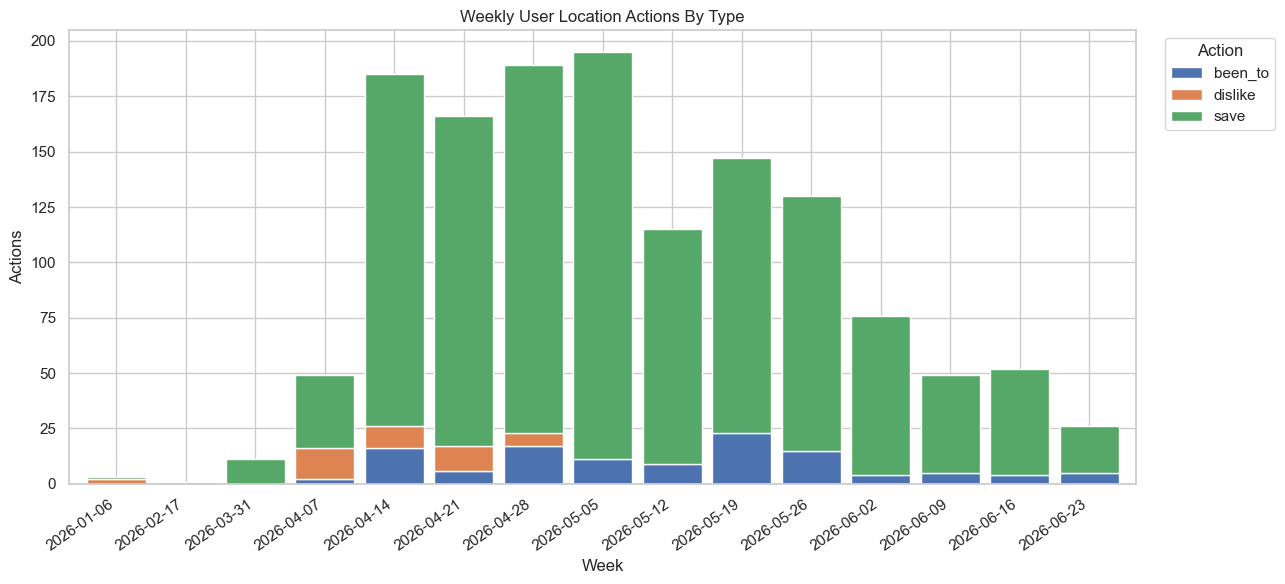

In [7]:
ax = weekly_actions.plot(kind="bar", stacked=True, figsize=(13, 6), width=0.85)
ax.set_title("Weekly User Location Actions By Type")
ax.set_xlabel("Week")
ax.set_ylabel("Actions")
ax.set_xticklabels([idx.strftime("%Y-%m-%d") for idx in weekly_actions.index], rotation=35, ha="right")
ax.legend(title="Action", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Feature And Action Usage

In [8]:
action_usage = (
    actions.groupby("action")
    .agg(actions=("action_id", "count"), users=("user_id", "nunique"), locations=("location_id", "nunique"))
    .sort_values("actions", ascending=False)
    .reset_index()
)
action_usage["action_share"] = action_usage["actions"] / action_usage["actions"].sum()
action_usage.to_csv(OUTPUT_DIR / "action_usage.csv", index=False)
action_usage

,action,actions,users,locations,action_share
0,save,1233,83,945,0.884505
1,been_to,117,35,101,0.083931
2,dislike,44,3,40,0.031564


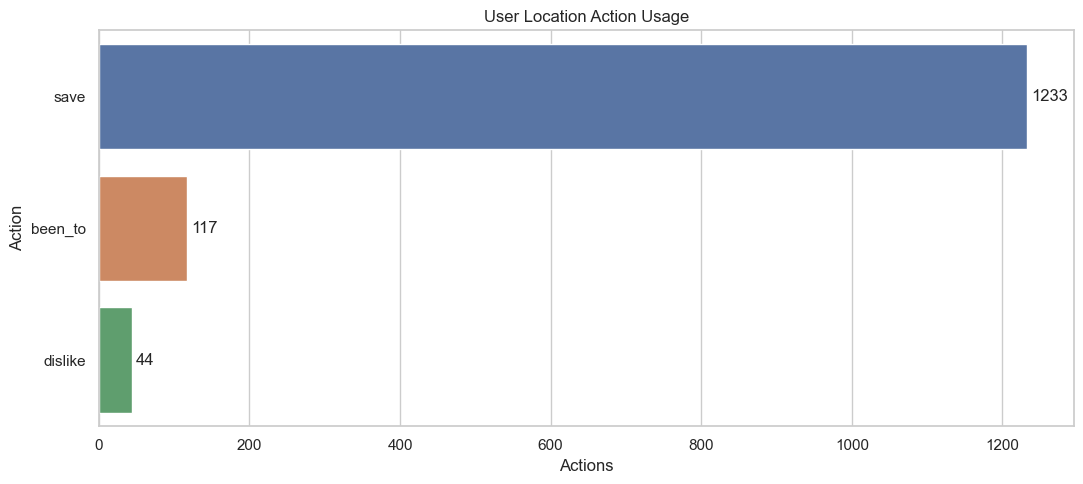

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=action_usage, x="actions", y="action", hue="action", dodge=False, legend=False, ax=ax)
ax.set_title("User Location Action Usage")
ax.set_xlabel("Actions")
ax.set_ylabel("Action")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()

In [10]:
if feature_usage.empty:
    print("No app_analytics_events rows available for feature usage.")
else:
    top_features = feature_usage.head(20)
    fig, ax = plt.subplots(figsize=(12, max(5, len(top_features) * 0.35)))
    sns.barplot(data=top_features, x="events", y="feature_or_event", hue="feature_or_event", dodge=False, legend=False, ax=ax)
    ax.set_title("Top App Features / Events")
    ax.set_xlabel("Events")
    ax.set_ylabel("Feature or event")
    plt.tight_layout()
    plt.show()

NameError: name 'feature_usage' is not defined

## Retained Users

In [ ]:
user_weeks = actions.dropna(subset=["user_id"])[["user_id", "week"]].drop_duplicates()
all_weeks = pd.Index(sorted(user_weeks["week"].unique()))
week_to_users = {week: set(group["user_id"]) for week, group in user_weeks.groupby("week")}
first_week_by_user = user_weeks.groupby("user_id")["week"].min()

retention_rows = []
for week in all_weeks:
    week_users = week_to_users.get(week, set())
    next_week = week + pd.Timedelta(days=7)
    next_users = week_to_users.get(next_week, set())
    next_4_week_users = set()
    for offset in range(1, 5):
        next_4_week_users |= week_to_users.get(week + pd.Timedelta(days=7 * offset), set())

    new_users = {user for user in week_users if first_week_by_user.get(user) == week}
    retained_next_week = week_users & next_users
    retained_next_4_weeks = week_users & next_4_week_users

    retention_rows.append(
        {
            "week": week,
            "active_users": len(week_users),
            "new_users": len(new_users),
            "returning_users": len(week_users - new_users),
            "retained_next_week_users": len(retained_next_week),
            "next_week_retention_rate": len(retained_next_week) / len(week_users) if week_users else np.nan,
            "retained_next_4_weeks_users": len(retained_next_4_weeks),
            "next_4_week_retention_rate": len(retained_next_4_weeks) / len(week_users) if week_users else np.nan,
        }
    )

weekly_retention = pd.DataFrame(retention_rows)
weekly_retention.to_csv(OUTPUT_DIR / "weekly_retention.csv", index=False)
weekly_retention.tail(12)

,week,active_users,new_users,returning_users,retained_next_week_users,next_week_retention_rate,retained_next_4_weeks_users,next_4_week_retention_rate
2,2026-03-31,1,0,1,1,1.000000,1,1.000000
3,2026-04-07,1,0,1,1,1.000000,1,1.000000
4,2026-04-14,15,14,1,9,0.600000,12,0.800000
5,2026-04-21,17,8,9,11,0.647059,13,0.764706
6,2026-04-28,23,12,11,12,0.521739,15,0.652174
7,2026-05-05,31,15,16,12,0.387097,16,0.516129
8,2026-05-12,24,8,16,10,0.416667,15,0.625000
9,2026-05-19,29,16,13,8,0.275862,11,0.379310
10,2026-05-26,21,8,13,7,0.333333,7,0.333333
11,2026-06-02,11,2,9,2,0.181818,2,0.181818


/var/folders/w5/q3g22k8d1_72830gw6496kz00000gn/T/ipykernel_88258/3662914248.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([ts.strftime("%Y-%m-%d") for ts in weekly_retention["week"]], rotation=35, ha="right")


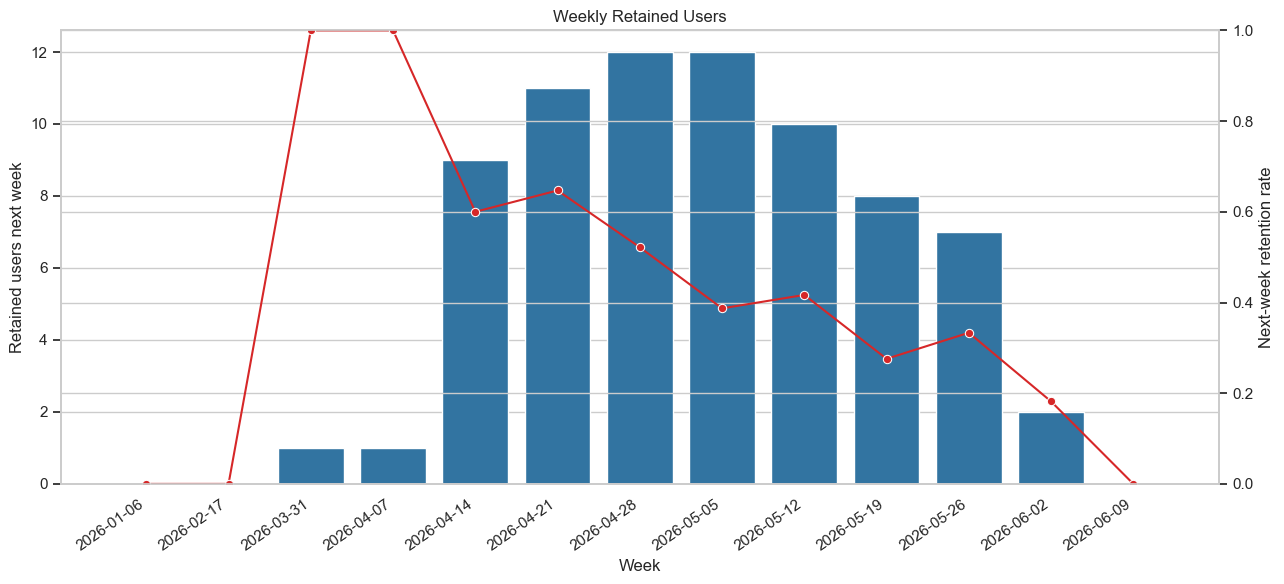

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 6))
sns.barplot(data=weekly_retention, x="week", y="retained_next_week_users", color="tab:blue", ax=ax1)
ax1.set_xlabel("Week")
ax1.set_ylabel("Retained users next week")
ax1.set_xticklabels([ts.strftime("%Y-%m-%d") for ts in weekly_retention["week"]], rotation=35, ha="right")

ax2 = ax1.twinx()
sns.lineplot(
    data=weekly_retention,
    x=np.arange(len(weekly_retention)),
    y="next_week_retention_rate",
    marker="o",
    color="tab:red",
    ax=ax2,
)
ax2.set_ylabel("Next-week retention rate")
ax2.set_ylim(0, 1)
ax1.set_title("Weekly Retained Users")
fig.tight_layout()
plt.show()

## Cohort Retention Heatmap

In [ ]:
cohort_activity = user_weeks.copy()
cohort_activity["cohort_week"] = cohort_activity["user_id"].map(first_week_by_user)
cohort_activity["week_number"] = ((cohort_activity["week"] - cohort_activity["cohort_week"]).dt.days // 7).astype(int)

cohort_counts = (
    cohort_activity.groupby(["cohort_week", "week_number"])["user_id"]
    .nunique()
    .reset_index(name="users")
)
cohort_sizes = cohort_counts[cohort_counts["week_number"] == 0][["cohort_week", "users"]].rename(columns={"users": "cohort_size"})
cohort_counts = cohort_counts.merge(cohort_sizes, on="cohort_week", how="left")
cohort_counts["retention_rate"] = cohort_counts["users"] / cohort_counts["cohort_size"]

cohort_matrix = cohort_counts.pivot(index="cohort_week", columns="week_number", values="retention_rate").sort_index()
cohort_matrix.to_csv(OUTPUT_DIR / "cohort_retention_rates.csv")
cohort_counts.to_csv(OUTPUT_DIR / "cohort_retention_counts.csv", index=False)

cohort_matrix.tail(12)

week_number,0,1,2,3,4,5,6,7,8,12,13,14,15,16,17,22
cohort_week,,,,,,,,,,,,,,,,
2026-01-06,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-04-14,1.0,0.571429,0.428571,0.571429,0.571429,0.357143,0.357143,0.214286,0.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-21,1.0,0.500000,0.250000,0.375000,0.125000,0.500000,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-28,1.0,0.416667,0.250000,0.250000,0.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-05,1.0,0.133333,0.200000,NaN,NaN,0.066667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-12,1.0,0.125000,0.125000,0.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-19,1.0,0.125000,0.062500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-26,1.0,0.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


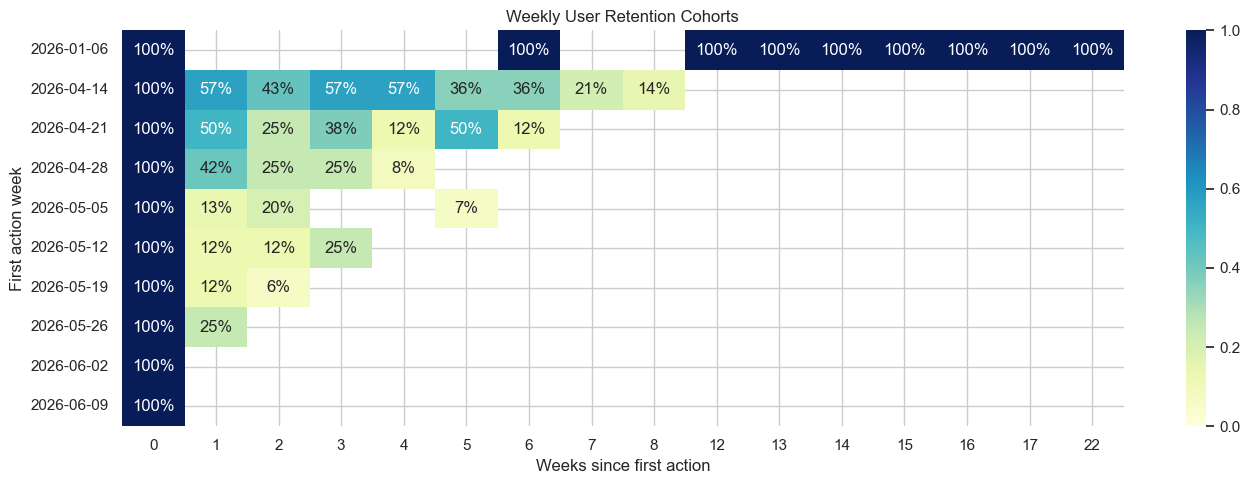

In [ ]:
if cohort_matrix.empty:
    print("No cohort data available.")
else:
    heatmap_data = cohort_matrix.copy()
    heatmap_data.index = heatmap_data.index.strftime("%Y-%m-%d")
    fig, ax = plt.subplots(figsize=(14, max(5, len(heatmap_data) * 0.35)))
    sns.heatmap(heatmap_data, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
    ax.set_title("Weekly User Retention Cohorts")
    ax.set_xlabel("Weeks since first action")
    ax.set_ylabel("First action week")
    plt.tight_layout()
    plt.show()

## High-Value Tables

In [ ]:
users

,supabase_id,name,username,email,created_at,wizard_completed,verified
0,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,Sri,help,123@gmail.com,2026-01-12T12:31:57.941121,True,False
1,a7e27f73-1bc5-461c-b3cb-fdad3813d139,Kailavya,kailavyakumar9155,kumak113.319@gmail.com,2026-04-15T11:23:39.647279,True,False
2,4b4538bf-b0dd-4533-ae88-0762e28e8281,Shlok,user5257,ishlokshah5@gmail.com,2026-04-15T11:26:31.142463,True,True
3,cb9c8a52-581b-466f-9a76-588532c4b5e9,Sri,sriharshavitta6372,sriharsha.vitta@gmail.com,2026-04-15T11:58:42.927157,True,False
4,d8c37612-57fb-4232-a062-685ffceebeca,Sriharsha Vitta,sriharshavitta6756,sriharsha.vitta@icloud.com,2026-04-15T12:22:05.498436,True,False
...,...,...,...,...,...,...,...
216,682abd80-198e-43a7-ab2c-204ac024880f,Serena BId,Serena,serenabid10@gmail.com,2026-06-07T18:23:42.415787,True,False
217,0678e564-3743-4c4f-a60f-743ac1cd97a4,prathamu11@gmail.com,pratham,prathamu11@gmail.com,2026-06-07T21:12:56.991393,True,False
218,5fc0311a-1736-41cf-9f53-4c66ca432eb2,Zinnay,Zinnay18,zinnay18@gmail.com,2026-06-08T13:54:54.702824,True,False
219,6a63e7f5-fb33-41d5-948e-487a52f49f6b,anjali,anjali,wadwa_anjali@outlook.com,2026-06-09T10:53:42.622464,True,False


In [ ]:
if "users" not in globals() or len(users) == 0:
    users = fetch_table(
        "users",
        select="supabase_id,name,username,email,created_at,wizard_completed,verified",
        order_col="created_at",
    )

top_users = (
    actions.groupby("user_id")
    .agg(
        actions=("action_id", "count"),
        active_weeks=("week", "nunique"),
        first_action=("created_at", "min"),
        last_action=("created_at", "max"),
        locations=("location_id", "nunique"),
    )
    .sort_values(["actions"], ascending=False)
    .reset_index()
)

user_profiles = users.copy()
if len(user_profiles) > 0:
    user_profiles = user_profiles.rename(
        columns={"supabase_id": "user_id", "created_at": "user_created_at"}
    )
    user_profiles["user_id"] = user_profiles["user_id"].astype("string")
    for column in ["name", "username", "email"]:
        user_profiles[column] = user_profiles[column].astype("string")
    user_profiles["display_name"] = (
        user_profiles["name"]
        .where(user_profiles["name"].notna() & user_profiles["name"].str.strip().ne(""))
        .fillna(user_profiles["username"])
        .fillna(user_profiles["email"])
        .fillna(user_profiles["user_id"])
    )
    top_users = top_users.merge(
        user_profiles[
            [
                "user_id",
                "display_name",
                "name",
                "username",
                "email",
                "wizard_completed",
                "verified",
                "user_created_at",
            ]
        ],
        on="user_id",
        how="left",
    )
    ordered_columns = [
        "user_id",
        "display_name",
        "name",
        "username",
        "email",
        "actions",
        "active_weeks",
        "locations",
        "first_action",
        "last_action",
        "wizard_completed",
        "verified",
        "user_created_at",
    ]
    top_users = top_users[[column for column in ordered_columns if column in top_users.columns]]

top_locations = (
    actions.groupby("location_id")
    .agg(actions=("action_id", "count"), users=("user_id", "nunique"), first_action=("created_at", "min"), last_action=("created_at", "max"))
    .sort_values("actions", ascending=False)
    .reset_index()
)

top_users.to_csv(OUTPUT_DIR / "top_users_by_activity.csv", index=False)
top_locations.to_csv(OUTPUT_DIR / "top_locations_by_activity.csv", index=False)

display(top_users.head(40))
display(top_locations.head(40))

,user_id,display_name,name,username,email,actions,active_weeks,locations,first_action,last_action,wizard_completed,verified,user_created_at
0,4b4538bf-b0dd-4533-ae88-0762e28e8281,Shlok,Shlok,user5257,ishlokshah5@gmail.com,294,9,285,2026-04-15 15:03:37.110750,2026-06-10 15:32:33.839093,True,True,2026-04-15T11:26:31.142463
1,cb9c8a52-581b-466f-9a76-588532c4b5e9,Sri,Sri,sriharshavitta6372,sriharsha.vitta@gmail.com,212,9,204,2026-04-15 16:35:06.574785,2026-06-10 15:56:19.520862,True,False,2026-04-15T11:58:42.927157
2,ab8232ba-5cfd-42be-8d94-2ef7e961e55f,Sri,Sri,help,123@gmail.com,125,9,116,2026-01-12 12:32:14.641107,2026-06-09 11:20:58.428818,True,False,2026-01-12T12:31:57.941121
3,c93a1d36-13f2-4599-85b6-60d4b1469891,Elisa Aslam,Elisa Aslam,elisa,elisaaslam@gmail.com,49,3,49,2026-05-09 16:49:11.597565,2026-05-24 20:55:58.635137,True,False,2026-05-09T16:44:11.6176
4,a7e27f73-1bc5-461c-b3cb-fdad3813d139,Kailavya,Kailavya,kailavyakumar9155,kumak113.319@gmail.com,36,6,35,2026-04-15 11:26:08.035365,2026-05-31 17:54:40.103422,True,False,2026-04-15T11:23:39.647279
5,26f0bdce-e413-41b5-b3e0-7d1b3d2cbbc7,Isaac,Isaac,isaacbutlerking1788,d6bvz7zyjz@privaterelay.appleid.com,30,1,30,2026-05-09 16:47:52.162754,2026-05-09 17:09:31.002405,True,False,2026-05-09T16:44:55.994252
6,71a6cd1e-fc3d-4a3b-b1dd-059a05e16dd1,Ayush Patel,Ayush Patel,ayushpatel7215,a4ayushpatel@gmail.com,29,7,29,2026-04-17 14:10:24.150192,2026-06-04 14:48:31.359299,True,False,2026-04-17T14:05:56.844184
7,a46a39d9-f8cb-487c-be5d-c88bf30a3e41,Alex Hollis,Alex Hollis,alexhollis3310,alexandra.hollis16@gmail.com,23,2,23,2026-06-01 09:10:53.984095,2026-06-04 18:07:16.282990,True,False,2026-05-29T08:44:56.969194
8,b2adfca4-308e-4350-8045-052132a0122a,mrew,mrew,syvtswcmb28641,syvtswcmb2@privaterelay.appleid.com,21,2,21,2026-05-08 20:58:54.377382,2026-05-19 14:55:27.416686,True,False,2026-05-08T20:53:58.185073
9,53f7398c-b6a3-47cf-99bf-482b523fa781,Joseph Podesta,Joseph Podesta,user9639,joseph.podesta@icloud.com,20,1,20,2026-04-28 13:38:58.187049,2026-04-29 20:30:05.299950,True,False,2026-04-28T13:36:40.599443


,location_id,actions,users,first_action,last_action
0,5853,30,28,2026-04-07 10:40:28.073279,2026-06-03 02:19:50.315270
1,6946,24,24,2026-04-16 16:35:13.748108,2026-05-26 18:55:51.210198
2,142110,18,18,2026-04-16 16:33:39.737471,2026-05-26 18:58:09.120990
3,1773,17,17,2026-04-16 16:36:06.865540,2026-05-02 23:04:53.124927
4,1634,7,7,2026-04-28 08:24:05.582101,2026-05-21 16:47:08.475630
5,1757,7,7,2026-04-16 16:28:53.742725,2026-04-29 18:52:35.480161
6,1871,7,6,2026-04-11 22:26:16.126486,2026-05-28 10:51:32.133680
7,22830,6,6,2026-04-15 17:49:10.145764,2026-06-06 09:15:36.413786
8,141640,6,5,2026-04-14 00:41:04.182447,2026-05-01 18:41:32.967734
9,119791,6,4,2026-04-15 00:06:58.359916,2026-06-01 21:01:22.920635


## Export Summary

In [ ]:
exported = sorted(path.name for path in OUTPUT_DIR.glob("*.csv"))
print(f"Wrote {len(exported)} CSV files to {OUTPUT_DIR}")
for name in exported:
    print(f"- {name}")

Wrote 9 CSV files to /Users/sriharshavitta/Projects/pinit-recommendations/output/analytics
- action_usage.csv
- cohort_retention_counts.csv
- cohort_retention_rates.csv
- feature_usage_from_app_analytics_events.csv
- top_locations_by_activity.csv
- top_users_by_activity.csv
- weekly_actions_by_type.csv
- weekly_retention.csv
- weekly_usage.csv
